In [1]:
import os
import sys

import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from qmplot import qqplot

import os
import sys
import yaml
import logging
import muon as mu
import pandas as pd
import cnmf
import scanpy as sc

# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src')

from Stage2_Evaluation.Metrics.src import (
    compute_perturbation_association,
)


/home/users/ymo/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# IO path
out_dir = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/012726_100k_cells_20iter_allHVG_torch_halsvar_batch_e7"
run_name = "012726_100k_cells_20iter_allHVG_torch_halsvar_batch_e7_all"

# resourse path
guide_annotation_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Data/300genes_guide_metadata_v43.tsv"

# keys 
data_key = 'rna'
prog_key = "cNMF"
categorical_key="timepoint"
organism = "human"
samples = ['d0', 'd1', 'd2', 'd3']

# define variables
number_run = 300
number_guide = 6

# run variables
components = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100 , 150, 200, 250, 300]
sel_threshs = [0.2, 2.0]

# Compute real perturbation test

In [ ]:
# Validate reference_targets: guide_annotation_path vs guide_annotation_key
# Load one mdata to check guide_targets values
first_k = components[0]
thresh_str = str(sel_threshs[0]).replace('.', '_')
mdata_check = mu.read(f'{out_dir}/{run_name}/adata/cNMF_{first_k}_{thresh_str}.h5mu')
mdata_targets = set(mdata_check[prog_key].uns['guide_targets'])
print(f"mdata guide_targets unique values: {mdata_targets}")

# Option A: from annotation file (path-based)
df_target = pd.read_csv(guide_annotation_path, sep="\t", index_col=0)
df_target_non = df_target[df_target["targeting"] == False]
reference_targets_from_path = df_target_non.index.values.tolist()
print(f"\nFrom guide_annotation_path (first 5): {reference_targets_from_path[:5]}")
print(f"Overlap with mdata guide_targets: {mdata_targets.intersection(reference_targets_from_path)}")

# Option B: key-based (recommended)
reference_targets_from_key = ['non-targeting']
print(f"\nFrom guide_annotation_key: {reference_targets_from_key}")
print(f"Overlap with mdata guide_targets: {mdata_targets.intersection(reference_targets_from_key)}")

# Decide which to use
if len(mdata_targets.intersection(reference_targets_from_path)) > 0:
    reference_targets = reference_targets_from_path
    print(f"\n-> Using path-based reference_targets ({len(reference_targets)} targets)")
elif len(mdata_targets.intersection(reference_targets_from_key)) > 0:
    reference_targets = reference_targets_from_key
    print(f"\n-> Using key-based reference_targets: {reference_targets}")
else:
    raise ValueError(
        f"No reference_targets found in mdata guide_targets. "
        f"Path gives names like {reference_targets_from_path[:3]}, "
        f"but mdata has group names like {list(mdata_targets)[:3]}. "
        f"Check your guide_annotation_path or use key-based reference_targets."
    )

del mdata_check

In [ ]:
# reference_targets is set by the validation cell above

for sel_thresh in sel_threshs:
    for k in components:  

        output_folder = f"{out_dir}/{run_name}/Evaluation/{k}_{str(sel_thresh).replace('.','_')}"

        os.makedirs(output_folder, exist_ok=True)

        # Load mdata
        mdata = mu.read('{out_dir}/{run_name}/adata/cNMF_{k}_{sel_thresh}.h5mu'.format(out_dir = out_dir,
                                                                                run_name =run_name,
                                                                                k=k,
                                                                                sel_thresh = str(sel_thresh).replace('.','_'))) 
                                                                        


        # Run perturbation assocation
        for samp in mdata['rna'].obs[categorical_key].unique():
            mdata_ = mdata[mdata['rna'].obs[categorical_key]==samp]
            test_stats_df = compute_perturbation_association(mdata_, prog_key=prog_key, 
                                                            collapse_targets=True,
                                                            pseudobulk=False,
                                                            reference_targets=reference_targets,
                                                            FDR_method = 'StoreyQ',
                                                            n_jobs=-1, inplace=False)

            test_stats_df.to_csv('{}/{}_perturbation_association_results_{}.txt'.format(output_folder,k,samp), sep='\t', index=False)

# Compute fake perturbation test

In [ ]:
# Load guide target
# Option 1: from annotation file
# guide_annotation_path = '/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Data/300genes_guide_metadata_v43.tsv' 
# guide_target = pd.read_csv(guide_annotation_path, sep='\t')
# non_targeting_idx = guide_target.index[guide_target.targeting==False]  
# guide_target = guide_target.loc[non_targeting_idx]
# guide_target['type'] = "non-targeting"

# Option 2: from mdata (no annotation file needed)
# Load one mdata to extract guide info
first_k = components[0]
first_thresh = sel_threshs[0]
thresh_str = str(first_thresh).replace('.', '_')
mdata_check = mu.read(f'{out_dir}/{run_name}/adata/cNMF_{first_k}_{thresh_str}.h5mu')

guide_targets_arr = mdata_check[prog_key].uns['guide_targets']
guide_names_arr = mdata_check[prog_key].uns['guide_names']
non_targeting_idx = np.where(guide_targets_arr == 'non-targeting')[0]
print(f'Non-targeting guides: {len(non_targeting_idx)}')

guide_target = pd.DataFrame({
    'guide_names': guide_names_arr[non_targeting_idx],
    'type': 'non-targeting'
})
del mdata_check

In [ ]:
# Calibrate tests using "fake_target guides"
test_stats_fake_dfs = []


for sel_thresh in sel_threshs:
    for k in components:  
        print(f"Processing K={k}, sel_thresh={sel_thresh}")

        # Load mdata
        output_folder = f"{out_dir}/{run_name}/Evaluation/{k}_{str(sel_thresh).replace('.','_')}"
        os.makedirs(output_folder, exist_ok=True)
        mdata = mu.read('{out_dir}/{run_name}/adata/cNMF_{k}_{sel_thresh}.h5mu'.format(out_dir = out_dir,
                                                                                run_name =run_name,
                                                                                k=k,
                                                                                sel_thresh = str(sel_thresh).replace('.','_')))  


        test_stats_fake_dfs_temp = []
        for i in range(number_run):
            print(f"Running iteration {i+1}/{number_run} for {k} and {sel_thresh}")       

            # randomly make number_guide non-targeting guides targeting 
            guide_target_ = guide_target.copy()
            selected_guides = np.random.choice(guide_target_.guide_names, number_guide, replace=False)
            guide_target_.loc[guide_target_.guide_names.isin(selected_guides), 'type'] = 'targeting'
            
            
            # Filter to only non-targeting guides that exist in both datasets
            valid_guide_mask = np.isin(mdata['cNMF'].uns['guide_names'], guide_target_.guide_names.values)
            valid_indices = np.where(valid_guide_mask)[0]
            
            print(f"Found {len(valid_indices)} valid non-targeting guides out of {len(mdata['cNMF'].uns['guide_names'])} total")
            
            if len(valid_indices) == 0:
                raise ValueError("No valid guides found")

            _mdata = mdata.copy()
            _mdata['cNMF'].obsm['guide_assignment'] = mdata['cNMF'].obsm['guide_assignment'][:, non_targeting_idx]
            _mdata['cNMF'].uns['guide_names'] = mdata['cNMF'].uns['guide_names'][non_targeting_idx]
            _mdata['cNMF'].uns['guide_targets'] = guide_target_.loc[guide_target_.guide_names.isin(mdata['cNMF'].uns['guide_names']), 'type'].values


            # Run perturbation assocation
            for samp in _mdata['rna'].obs[categorical_key].unique():
                mdata_samp = _mdata[_mdata['rna'].obs[categorical_key]==samp]
                test_stats_df = compute_perturbation_association(mdata_samp, prog_key=prog_key, 
                                                                collapse_targets=True,
                                                                pseudobulk=False,
                                                                reference_targets=['non-targeting'],
                                                                FDR_method = 'BH',
                                                                n_jobs=-1, inplace=False)

                test_stats_df[categorical_key] = samp
                test_stats_df['K'] = k
                test_stats_df['run'] = i
                test_stats_df['sel_thresh'] = sel_thresh
                test_stats_fake_dfs.append(test_stats_df) # combine all
                test_stats_fake_dfs_temp.append(test_stats_df) # combine for each k and sel_thresh

        # save fake test results per condition
        test_stats_fake_dfs_temp = pd.concat(test_stats_fake_dfs_temp, ignore_index=True)
        for samp, samp_df in test_stats_fake_dfs_temp.groupby(categorical_key):
            samp_df.to_csv(f'{output_folder}/{k}_fake_perturbation_association_results_{samp}.txt', sep='\t', index=False)

# compare

In [ ]:
# or load this way 

# if already have peturbation test data, read data 
test_stats_real_df = []

for sel_thresh in sel_threshs:
    for k in components:  
        for samp in samples:
            thresh_str = str(sel_thresh).replace('.', '_')
            test_stats_df_ = pd.read_csv(f'{out_dir}/{run_name}/Evaluation/{k}_{thresh_str}/{k}_perturbation_association_results_{samp}.txt', sep='\t')
            test_stats_df_['sample'] = samp
            test_stats_df_['K'] = k
            test_stats_df_['sel_thresh'] = sel_thresh
            #test_stats_df_['fdr'] = fdrcorrection(test_stats_df_['pval'])[1]
            test_stats_real_df.append(test_stats_df_)

# Concatenate AFTER all loops are done
test_stats_real_df = pd.concat(test_stats_real_df, ignore_index=True)
test_stats_real_df['real'] = True

# if already have fake peturbation test data, read data 
# test_stats_fake_dfs = pd.read_csv('/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/perturbation_association_calibration.txt', sep='\t')

# or load this way
test_stats_fake_df = []
for sel_thresh in sel_threshs:
    for k in components:  
        thresh_str = str(sel_thresh).replace('.', '_')
        test_stats_df_ = pd.read_csv(f'{out_dir}/{run_name}/Evaluation/{k}_{thresh_str}/{k}_fake_perturbation_association_results.txt', sep='\t')
        #test_stats_df_['fdr'] = fdrcorrection(test_stats_df_['pval'])[1]
        test_stats_fake_df.append(test_stats_df_)

# Concatenate AFTER all loops are done
test_stats_fake_df = pd.concat(test_stats_fake_df, ignore_index=True)
test_stats_fake_df['real'] = False

# merge
test_stats_dfs = pd.concat([test_stats_real_df, test_stats_fake_df])

In [ ]:
# or load this way 

# if already have peturbation test data, read data 
test_stats_real_df = []

for sel_thresh in sel_threshs:
    for k in components:  
        for samp in samples:
            thresh_str = str(sel_thresh).replace('.', '_')
            test_stats_df_ = pd.read_csv(f'{out_dir}/{run_name}/Evaluation/{k}_{thresh_str}/{k}_perturbation_association_results_{samp}.txt', sep='\t')
            test_stats_df_['sample'] = samp
            test_stats_df_['K'] = k
            test_stats_df_['sel_thresh'] = sel_thresh
            test_stats_real_df.append(test_stats_df_)

# Concatenate AFTER all loops are done
test_stats_real_df = pd.concat(test_stats_real_df, ignore_index=True)
test_stats_real_df['real'] = True

# load fake perturbation test data (per condition)
test_stats_fake_df = []
for sel_thresh in sel_threshs:
    for k in components:  
        for samp in samples:
            thresh_str = str(sel_thresh).replace('.', '_')
            test_stats_df_ = pd.read_csv(f'{out_dir}/{run_name}/Evaluation/{k}_{thresh_str}/{k}_fake_perturbation_association_results_{samp}.txt', sep='\t')
            test_stats_fake_df.append(test_stats_df_)

# Concatenate AFTER all loops are done
test_stats_fake_df = pd.concat(test_stats_fake_df, ignore_index=True)
test_stats_fake_df['real'] = False

# merge
test_stats_dfs = pd.concat([test_stats_real_df, test_stats_fake_df])

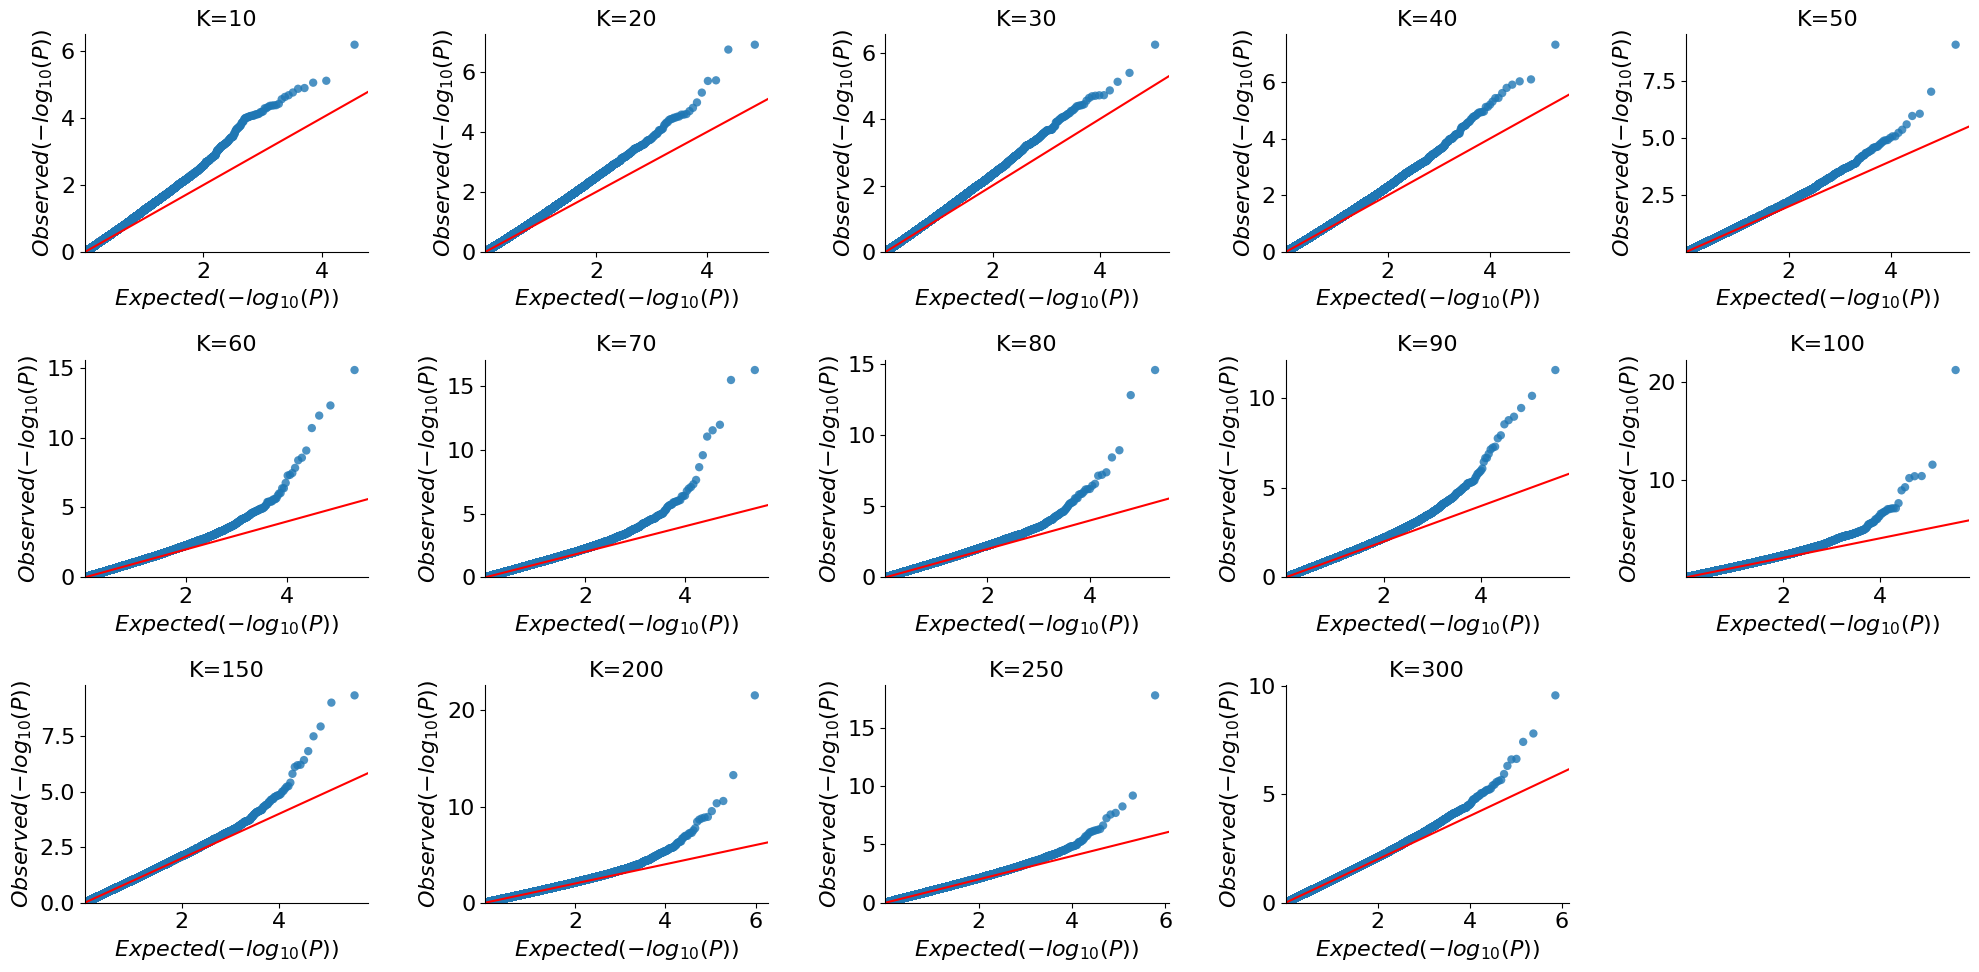

In [ ]:
 # QQ plot fake
nrows = int(len(components)/4) +1 

fig, axs = plt.subplots(ncols=4, nrows=nrows, figsize=(20,10))
for i,k in enumerate(components):

    qqplot(data=test_stats_dfs.loc[(test_stats_dfs.K==k) & (test_stats_dfs.real==False)& (test_stats_dfs.target_name=='targeting'), 'pval'], ax=axs.flat[i])
    axs.flat[i].set_title(f'K={k}')

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig(f'{out_dir}/{run_name}/Plot/QQ_plot/perturbation_association_qqplot_fake.png', dpi=100)

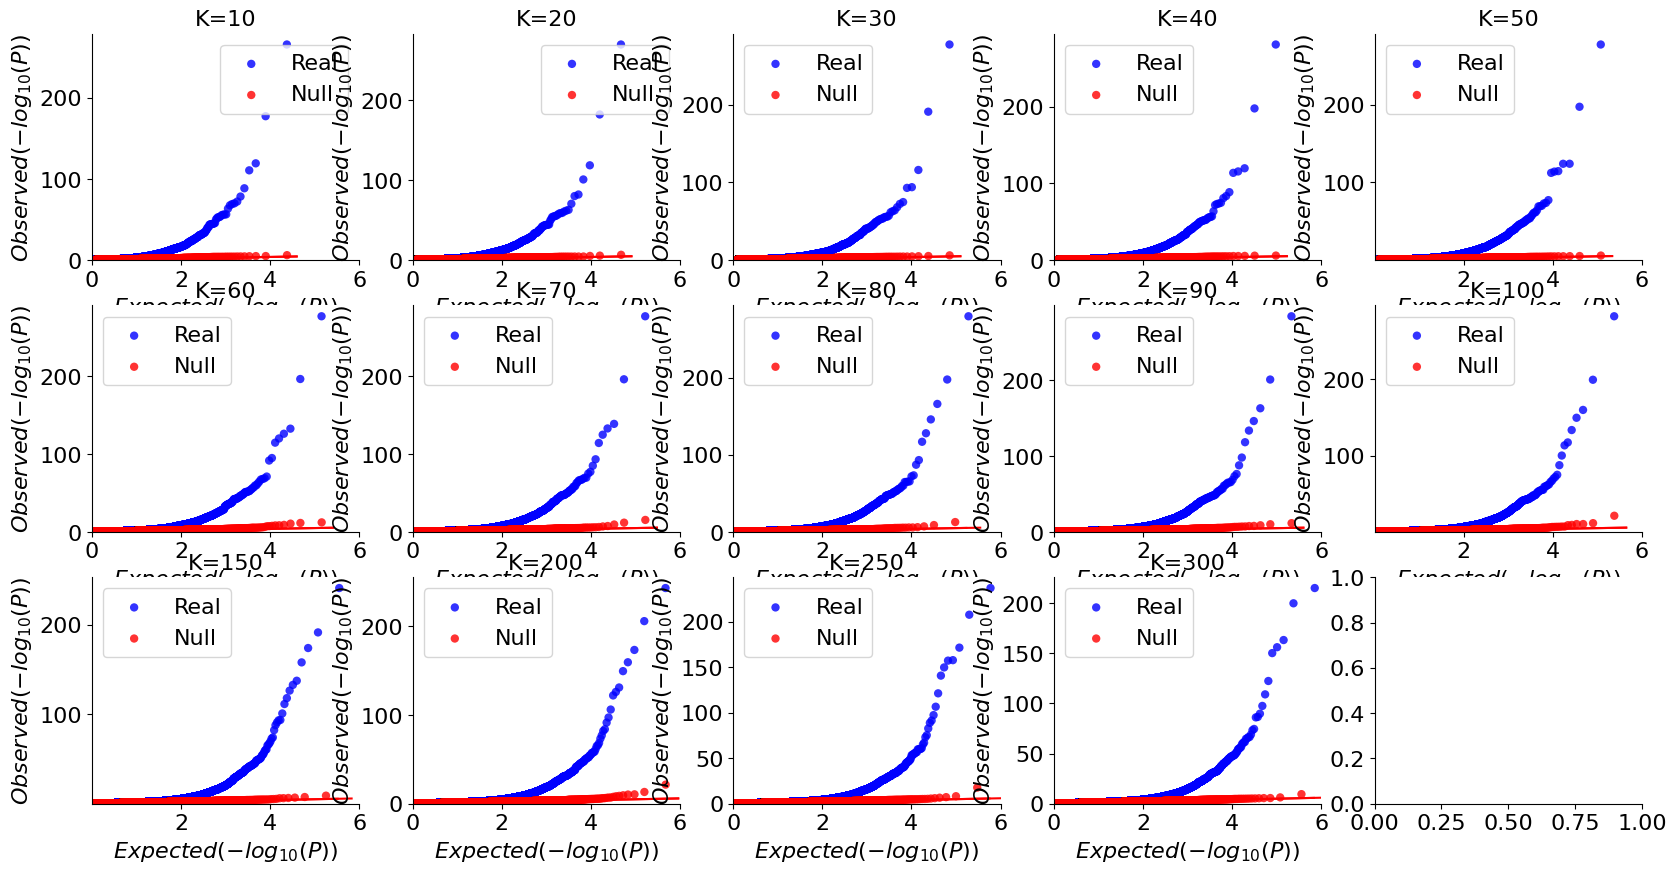

In [ ]:
# combine 
nrows = int(len(components)/4) +1 
fig, axs = plt.subplots(ncols=4, nrows=nrows, figsize=(20, 10))

sel_thresh = 0.2

for i, k in enumerate(components):
    ax = axs.flat[i]
    
    # Get data for both real and null
    real_pvals = test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == True) & (test_stats_dfs.sel_thresh == sel_thresh), 'pval']
    null_pvals = test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == False) & (test_stats_dfs.target_name == 'targeting') & (test_stats_dfs.sel_thresh == sel_thresh), 'pval']
    
    # Real data
    qqplot(
        data=real_pvals,
        ax=ax,
        color='blue',
        label='Real'
    )
    
    # Null data
    qqplot(
        data=null_pvals,
        ax=ax,
        color='red',
        label='Null'
    )
    
    # Get current axis limits (after both plots are drawn)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Expand limits independently to include all data from both axes
    max_x = max(xlim[1], ylim[0])
    min_x = min(xlim[0], ylim[0])
    max_y = max(xlim[1], ylim[1])
    min_y = min(xlim[0], ylim[0])
    
    ax.set_xlim(min_x, 6)
    ax.set_ylim(min_y, max_y)
    
    ax.set_title(f'K={k}')
    ax.legend()

plt.savefig(f'{out_dir}/{run_name}/Plot/QQ_plot/perturbation_association_qqplot_overlap_{str(sel_thresh).replace(".", "_")}.png', dpi=100)